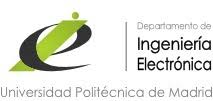

<div align="center">


# **Reconocimiento de gestos con la mano (Hand Gesture Recognition)**
### **Versión del 7 de Marzo de 2026**
---
---

</div>

In many contexts, having information about the movements of a person can be highly beneficial for diagnosing certain diseases. Parkinson's disease serves as a prime example, as it is a progressive disorder that affects the nervous system and impairs movement. In some cases, the disease initially manifests as subtle tremors that may not be visible to the naked eye but can be easily detected by an inertial sensor. To expand on the concept further, it is worth considering the utility of detecting landmarks from images and videos of individuals in real-time. Landmark detection involves identifying specific points or features of interest on a person's body, such as joints, facial landmarks, or key anatomical landmarks. These landmarks provide crucial information about the position, orientation, and movement of various body parts.  By leveraging computer vision techniques, cameras or video sensors can capture real-time images or video footage of individuals and detect the positions of these landmarks. This information can be invaluable for a wide range of applications, including  Gesture Recognition: Landmark detection enables the tracking and analysis of hand gestures or body movements. By recognizing specific patterns and trajectories of landmarks, it becomes possible to develop gesture recognition systems that can interpret and understand human movements.


1.   Biomechanical Analysis: Detecting landmarks from images or videos allows for the analysis of human biomechanics. By tracking the positions and movements of anatomical landmarks, it becomes possible to study and evaluate body mechanics, identify abnormalities, and aid in the diagnosis and treatment of musculoskeletal disorders.


2.   Physical Rehabilitation: Landmark detection can be employed in physical
rehabilitation settings to track and analyze a patient's movements during therapy sessions. By monitoring the positions and trajectories of specific landmarks, therapists can assess the progress of rehabilitation exercises and provide real-time feedback to patients.

3.  Human-Computer Interaction: By detecting landmarks, devices such as cameras or depth sensors can enable natural and intuitive interaction between humans and computers. This technology can facilitate applications like virtual reality, augmented reality, or touchless interfaces that respond to specific gestures or body movements.  To utilize landmark detection from images or video in real-time scenarios, advanced computer vision algorithms and techniques are employed.

These algorithms analyze the visual data, identify and track the desired landmarks, and extract meaningful information for further processing or application-specific tasks.


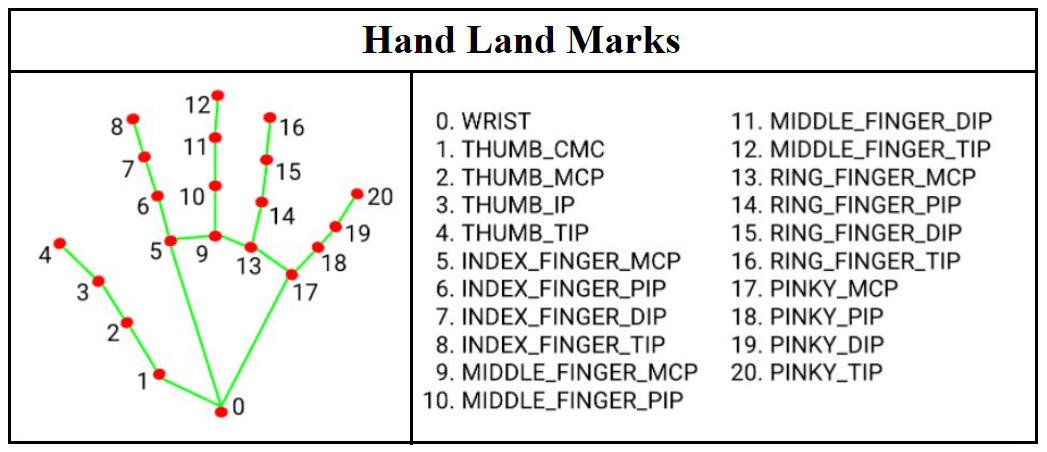






**Data Analysis**

For the purpose of our analysis, we will be working with the landmarks extracted from the images. These landmarks provide information about the position and orientation.
Our goal will be to develop models or perform analysis to discern between the different gestures based on the extracted landmarks. This could involve tasks such as gesture recognition, activity classification...


**Summary**

This practice is dedicated to the familiarization with the tools introduced during the course, more specifically, to mediapipe and Tensorflow.

The main concepts that we will work are:

1. Firstly, we will extract, interpret, and work with landmarks from different images. This involves extracting the relevant features or points of interest from the images and representing them as landmarks.
2. Secondly, we will train multiple models using the extracted landmarks. We will analyze the performance and predictions of each model, evaluating metrics such as accuracy, precision, recall, and F1-score. This step allows us to assess how well each model performs in recognizing and classifying gestures based on the landmarks
3. Thirdly, we will compare the performance of the different models and make any necessary adjustments or refinements. This may involve fine-tuning the models' hyperparameters, adding more data to improve generalization, or applying techniques to address specific challenges or limitations. The goal is to select the most suitable model that achieves the best overall performance in classifying the gestures based on the landmarks.

# Workspace preparation

## Google Drive personal folder mount
The project will be executed in a folder that the student must upload to Google Drive with the database. The files generated throughout the practice, such as models, predictions, etc., will be saved in this folder


In [1]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

# Clonar el repositorio sin descargar todo el contenido
!git clone --filter=blob:none --no-checkout https://github.com/efhes/IE-workspace.git

%cd IE-workspace

# Activar sparse checkout
!git sparse-checkout init --cone

# Seleccionar las carpetas necesarias
!git sparse-checkout set HAR_mediapipe common

# Descargar solo esas carpetas
!git checkout

Mounted at /content/drive
Cloning into 'IE-workspace'...
remote: Enumerating objects: 415, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 415 (delta 19), reused 17 (delta 7), pack-reused 383 (from 1)
Receiving objects: 100% (415/415), 67.76 KiB | 598.00 KiB/s, done.
Resolving deltas: 100% (162/162), done.
/content/IE-workspace
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 333 (delta 3), reused 2 (delta 1), pack-reused 320 (from 1)
Receiving objects: 100% (333/333), 82.05 MiB | 22.02 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (335/335), done.
Your branch is up to date with 'origin/master'.


## MediaPipe installation

Let's start with installing MediaPipe.

In [2]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.2 MB/s eta 0:00:00


## Import required libraries

In this section, we will download and import all the neccessary packages for running the experiments.

Among the packages and libraries installed, the most important are:

* **Mediapipe** is an open-source framework developed by Google that provides a comprehensive pipeline for building multimodal (audio, video, and sensor) applications. It offers a wide range of pre-built and customizable machine learning models and processing modules, making it easier to develop complex multimedia applications.
* **pandas**: Python library that lets deal with csv and convert them to a DataFrame, type of data organization in a kind of table format.
* **tensorflow**: Open source software library for numerical computation using data-flow graphs and for implementing and training artificial neural networks.
* **numpy**: This Python library is oriented to make numeric operactions, algebra and mathematic analysis.
* **matplotlib**: This Python library contains graphic plot functions, similr to the resources available in Matlab for showing graphs.




In [3]:

!pip install mediapipe opencv-python tensorflow wandb scikit-learn pandas keras matplotlib seaborn

## Path definition and libs import checking

In [4]:
import sys

sys.path.append('/content/IE-workspace/HAR_mediapipe/src/')
sys.path.append("/content/IE-workspace/common/")

import landmarksLib
print("Recursos de landmarksLib:", dir(landmarksLib)) # To check if it works

import config
print("Recursos de common:", dir(config)) # To check if it works

Recursos de landmarksLib: ['ArrangeInputDataForNetwork', 'FONT_SIZE', 'FONT_THICKNESS', 'GetLandmarksFromImages', 'GetLandmarksListFromDetectionResult', 'HANDEDNESS_TEXT_COLOR', 'MARGIN', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'create_numpy_with_feats_and_csv_with_just_labels', 'cv2', 'draw_landmarks_on_image', 'extract_classes_list_from_folders', 'get_XYZ', 'load_individual_class_features_and_create_labeled_csv_dataset', 'mp', 'mp_drawing', 'mp_drawing_styles', 'mp_hands', 'normalize_from_0_landmark', 'np', 'os', 'pd', 'remove_last_subfolder', 'sorted_lists_match']
Recursos de common: ['Config', 'ConfigMediapipeDetector', 'RecordingSetup', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'lib_path', 'mp', 'os', 'python', 'random', 'sys', 'vision', 'wait_for_keypress']


## ONLY WHEN EXECUTING FROM DESKTOP, NOT FROM GOOGLE COLAB

### Required Python libraries

In [ ]:
%pip install tensorflow keras pandas numpy mediapipe opencv-python scikit-learn wandb matplotlib seaborn

### Path definition and libs import checking

In [ ]:
import os
import sys

# 1. Cambiar al directorio raíz del proyecto
%cd ~/workspace/IE-workspace/

# 2. Definir rutas ABSOLUTAS para evitar ambigüedades
root_path = os.getcwd()
path_har = os.path.join(root_path, "HAR_mediapipe", "src")
path_common = os.path.join(root_path, "common")

# 3. Añadirlas al path y verificar si existen
for p in [path_har, path_common]:
    if p not in sys.path:
        sys.path.append(p)
    if not os.path.exists(p):
        print(f"⚠️ ¡OJO! La ruta no existe: {p}")
    else:
        print(f"✅ Ruta añadida: {p}")

# 4. Intentar la importación
try:
    import landmarksLib
    print("🚀 landmarksLib importado con éxito")
except ModuleNotFoundError as e:
    print(f"❌ Error: {e}")

# 4. Intentar la importación
try:
    import config
    print("🚀 config importado con éxito")
except ModuleNotFoundError as e:
    print(f"❌ Error: {e}")

[Errno 2] No such file or directory: '/root/workspace/IE-workspace/'
/content/IE-workspace
✅ Ruta añadida: /content/IE-workspace/HAR_mediapipe/src
✅ Ruta añadida: /content/IE-workspace/common
🚀 landmarksLib importado con éxito
🚀 config importado con éxito


## Data folder specification

Links to the folder containing the database of images that will be used. **Please, note that the name of the subfolder containing the data must be updated accordingly if you wan to work with a different dataset.**

In [5]:
# =============================================================================
# Rutas del proyecto
# =============================================================================
# Las rutas de abajo son RELATIVAS, así que dependen del directorio de trabajo.
# Si el runtime se reinicia y no se vuelve a ejecutar la celda del git clone
# (la que hace "cd IE-workspace"), el directorio vuelve a ser /content y todo
# el pipeline falla con FileNotFoundError al buscar
# 'HAR_mediapipe/data/new_dataset_final/train/'. Esto lo detecta y lo corrige.
import os

for _cand in ['/content/IE-workspace',
              os.getcwd(),
              os.path.join(os.getcwd(), 'IE-workspace'),
              os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, 'HAR_mediapipe')):
        if os.path.abspath(_cand) != os.path.abspath(os.getcwd()):
            os.chdir(_cand)
            print('[Directorio de trabajo corregido]')
        break
else:
    print('[AVISO] No encuentro la carpeta HAR_mediapipe desde %s' % os.getcwd())
    print('        Ejecuta la celda del git clone (la que hace "cd IE-workspace").')

print('[Directorio de trabajo actual: %s]\n' % os.getcwd())

root_path = r'HAR_mediapipe/' # r'/content/IE-workspace/HAR_mediapipe/'

# Folder where the input data is saved
data_path = root_path + r'data/'
new_dataset_path = data_path + r'new_dataset_final/' # Change 'new_dataset' as needed
new_dataset_annotations_path = new_dataset_path + r'annotations/'
new_dataset_landmarks_path = new_dataset_path + r'landmarks/'
dataset_path = {}
dataset_path['train'] = new_dataset_path + r'train/'
dataset_path['test'] = new_dataset_path + r'test/'

# Folder where the models are stored
models_path = root_path + r'models/'

# SUMMARY
print('data_path = ', data_path)
print('new_dataset_path = ', new_dataset_path)
print('new_dataset_annotations_path = ', new_dataset_annotations_path)
print('new_dataset_landmarks_path = ', new_dataset_landmarks_path)
print('dataset_path[train] = ', dataset_path['train'])
print('dataset_path[test] = ', dataset_path['test'])
print('models_path = ', models_path)

# --- Comprobación: ¿está el dataset donde estas rutas apuntan? --------------
if os.path.isdir(dataset_path['train']) and os.path.isdir(dataset_path['test']):
    print('\n[OK] Dataset encontrado en %s' % os.path.abspath(new_dataset_path))
else:
    print('\n[AVISO] No hay dataset en %s' % os.path.abspath(new_dataset_path))
    print('        Ejecuta la celda "Dataset del equipo: localizar en Drive,')
    print('        copiar y descomprimir" antes de seguir.')

[Directorio de trabajo actual: /content/IE-workspace]

data_path =  HAR_mediapipe/data/
new_dataset_path =  HAR_mediapipe/data/new_dataset_final/
new_dataset_annotations_path =  HAR_mediapipe/data/new_dataset_final/annotations/
new_dataset_landmarks_path =  HAR_mediapipe/data/new_dataset_final/landmarks/
dataset_path[train] =  HAR_mediapipe/data/new_dataset_final/train/
dataset_path[test] =  HAR_mediapipe/data/new_dataset_final/test/
models_path =  HAR_mediapipe/models/

[AVISO] No hay dataset en /content/IE-workspace/HAR_mediapipe/data/new_dataset_final
        Ejecuta la celda "Dataset del equipo: localizar en Drive,
        copiar y descomprimir" antes de seguir.


## Dataset del equipo desde Google Drive

El `.zip` del dataset está en **Compartido conmigo → Grabaciones PIDS**, y esa sección de Drive **no es accesible desde Colab**: al montar Drive sólo se ve *Mi unidad* (`/content/drive/MyDrive`) y las *unidades compartidas*.

**Configúralo una sola vez (30 segundos):** en Drive, clic derecho sobre la carpeta **Grabaciones PIDS** (o sobre el propio `new_dataset_final.zip`) → **Organizar** → **Añadir acceso directo** → **Mi unidad**.

El acceso directo no duplica el fichero ni ocupa cuota: es un puntero al original, así que si el equipo sube una versión nueva del `.zip`, tú la ves automáticamente.

Hecho eso, la celda siguiente localiza el `.zip`, lo copia al disco local de Colab y lo descomprime sola. **Ya no hace falta arrastrar 64 MB a Colab en cada sesión**, que era el paso que había que repetir cada vez que se desconectaba.

In [6]:
# =============================================================================
# Dataset del equipo: localizar en Drive, copiar y descomprimir
# =============================================================================
# Requisito: acceso directo en "Mi unidad" a la carpeta 'Grabaciones PIDS' o al
# propio 'new_dataset_final.zip' (ver celda anterior).
import os, glob, time, shutil, zipfile

ZIP_NAME = 'new_dataset_final.zip'
FORZAR = False        # True para rehacer la descompresión aunque ya esté extraído

# --- 0) Raíz del workspace (vale en Colab y ejecutando en local) ------------
WORKSPACE = next((p for p in ['/content/IE-workspace',
                              os.getcwd(),
                              os.path.join(os.getcwd(), 'IE-workspace'),
                              os.path.dirname(os.getcwd())]
                  if os.path.isdir(os.path.join(p, 'HAR_mediapipe'))),
                 '/content/IE-workspace')
DATA_DIR    = os.path.join(WORKSPACE, 'HAR_mediapipe', 'data') + os.sep
DATASET_DIR = DATA_DIR + 'new_dataset_final' + os.sep
print('[Workspace][%s]' % WORKSPACE)

# --- 1) Montar Drive si estamos en Colab ------------------------------------
try:
    import google.colab  # noqa: F401
    ES_COLAB = True
except ImportError:
    ES_COLAB = False

if ES_COLAB and not os.path.isdir('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

# --- 2) ¿Ya está extraído de una ejecución anterior? ------------------------
ya_extraido = os.path.isdir(DATASET_DIR + 'train') and os.path.isdir(DATASET_DIR + 'test')

if ya_extraido and not FORZAR:
    print('[El dataset ya está en %s — no se repite la descompresión]' % DATASET_DIR)
else:
    # --- 3) Localizar el .zip en Mi unidad ---------------------------------
    if ES_COLAB:
        candidatos = [
            '/content/drive/MyDrive/' + ZIP_NAME,
            '/content/drive/MyDrive/Grabaciones PIDS/' + ZIP_NAME,
            '/content/drive/MyDrive/PIDS/' + ZIP_NAME,
            '/content/drive/MyDrive/PIDS/Grabaciones PIDS/' + ZIP_NAME,
        ]
    else:
        # Ejecutando en local: el zip estará en el propio repo o a mano
        candidatos = [
            DATA_DIR + ZIP_NAME,
            os.path.join(os.getcwd(), ZIP_NAME),
            os.path.expanduser('~/Downloads/' + ZIP_NAME),
            os.path.expanduser('~/Descargas/' + ZIP_NAME),
        ]
    zip_path = next((p for p in candidatos if os.path.exists(p)), None)

    if zip_path is None and ES_COLAB:
        print('[No está en las rutas habituales; buscando en Mi unidad (puede tardar)...]')
        encontrados = sorted(glob.glob('/content/drive/MyDrive/**/' + ZIP_NAME, recursive=True))
        if len(encontrados) > 1:
            print('[Hay %d copias, se usará la primera:]' % len(encontrados))
            for _p in encontrados:
                print('\t', _p)
        zip_path = encontrados[0] if encontrados else None

    if zip_path is None:
        raise FileNotFoundError(
            "No encuentro '%s' en tu Drive.\n\n"
            "El fichero está en 'Compartido conmigo', que Colab no puede ver.\n"
            "Solución (una sola vez): en Google Drive, clic derecho sobre la carpeta\n"
            "'Grabaciones PIDS' (o sobre el propio %s) -> Organizar ->\n"
            "Añadir acceso directo -> Mi unidad. Después vuelve a ejecutar esta celda.\n"
            "Si acabas de crearlo, ejecuta drive.flush_and_unmount() y vuelve a montar."
            % (ZIP_NAME, ZIP_NAME))

    print('[ZIP localizado][%s][%.1f MB]' % (zip_path, os.path.getsize(zip_path) / 1024**2))

    # --- 4) Copiar a disco local: leer 64 MB por el montaje de Drive es lento
    local_zip = ('/content/' + ZIP_NAME) if ES_COLAB else zip_path
    if os.path.abspath(local_zip) == os.path.abspath(zip_path):
        print('[El zip ya está en disco local, no hace falta copiarlo]')
    elif os.path.exists(local_zip) and os.path.getsize(local_zip) == os.path.getsize(zip_path):
        print('[Ya existe una copia local idéntica en %s]' % local_zip)
    else:
        _t0 = time.time()
        shutil.copy(zip_path, local_zip)
        print('[Copiado a %s en %.1f s]' % (local_zip, time.time() - _t0))

    # --- 5) Descomprimir (sobrescribe sin preguntar, a diferencia de !unzip)
    _t0 = time.time()
    with zipfile.ZipFile(local_zip) as z:
        nombres = [n for n in z.namelist() if not n.startswith('__MACOSX')]
        con_carpeta_raiz = all(n.startswith('new_dataset_final/') for n in nombres)
        destino = DATA_DIR if con_carpeta_raiz else DATASET_DIR
        os.makedirs(destino, exist_ok=True)
        z.extractall(destino)
    print('[Descomprimido en %s en %.1f s]' % (destino, time.time() - _t0))

# --- 6) Comprobación del contenido ------------------------------------------
# Esperado: 133 imágenes por gesto en train (132 en OK) y 57 por gesto en test.
print('\n[COMPROBACIÓN DEL DATASET]')
_totales = {}
for _split, _esperado in [('train', 797), ('test', 342)]:
    _base = DATASET_DIR + _split + '/'
    if not os.path.isdir(_base):
        print('\t[ERROR] No existe %s' % _base)
        _totales[_split] = -1
        continue
    print('\t=== %s ===' % _split.upper())
    _total = 0
    for _gesto in sorted(os.listdir(_base)):
        _n = len(os.listdir(_base + _gesto))
        _total += _n
        print('\t\t%-18s %4d' % (_gesto + ':', _n))
    _totales[_split] = _total
    print('\t\t%-18s %4d   (esperadas %d)' % ('TOTAL:', _total, _esperado))

if _totales.get('train') == 797 and _totales.get('test') == 342:
    print('\n[OK] El dataset coincide con el del equipo (1139 imágenes).')
else:
    print('\n[AVISO] Los totales no cuadran con los 797/342 esperados.'
          '\n        Comprueba que el .zip es el bueno y que la copia terminó entera'
          '\n        (pon FORZAR = True y vuelve a ejecutar para rehacerla).')

[Workspace][/content/IE-workspace]
[ZIP localizado][/content/drive/MyDrive/new_dataset_final.zip][64.2 MB]
[Copiado a /content/new_dataset_final.zip en 3.0 s]
[Descomprimido en /content/IE-workspace/HAR_mediapipe/data/ en 1.7 s]

[COMPROBACIÓN DEL DATASET]
	=== TRAIN ===
		No_Ok:              133
		OK:                 132
		Perfecto:           133
		Puno_de_frente:     133
		Spiderman:          133
		Uno:                133
		TOTAL:              797   (esperadas 797)
	=== TEST ===
		No_Ok:               57
		OK:                  57
		Perfecto:            57
		Puno_de_frente:      57
		Spiderman:           57
		Uno:                 57
		TOTAL:              342   (esperadas 342)

[OK] El dataset coincide con el del equipo (1139 imágenes).


In [7]:
!ls /content/IE-workspace/HAR_mediapipe/data/new_dataset_final/train/
!ls /content/IE-workspace/HAR_mediapipe/data/new_dataset_final/test/

No_Ok  OK  Perfecto  Puno_de_frente  Spiderman	Uno
No_Ok  OK  Perfecto  Puno_de_frente  Spiderman	Uno


In [8]:
!ls /content/IE-workspace/HAR_mediapipe/data/

new_dataset  new_dataset_final


In [9]:
print("=== TRAIN ===")
import os
for gesto in sorted(os.listdir('/content/IE-workspace/HAR_mediapipe/data/new_dataset_final/train/')):
    path = f'/content/IE-workspace/HAR_mediapipe/data/new_dataset_final/train/{gesto}'
    n = len(os.listdir(path))
    print(f"{gesto}: {n}")

print("\n=== TEST ===")
for gesto in sorted(os.listdir('/content/IE-workspace/HAR_mediapipe/data/new_dataset_final/test/')):
    path = f'/content/IE-workspace/HAR_mediapipe/data/new_dataset_final/test/{gesto}'
    n = len(os.listdir(path))
    print(f"{gesto}: {n}")

=== TRAIN ===
No_Ok: 133
OK: 132
Perfecto: 133
Puno_de_frente: 133
Spiderman: 133
Uno: 133

=== TEST ===
No_Ok: 57
OK: 57
Perfecto: 57
Puno_de_frente: 57
Spiderman: 57
Uno: 57


In [10]:
!ls /content/IE-workspace/HAR_mediapipe/models/

Five_Four_Three_CNN1.json   new_model_CNN1.json        pose_landmarker.task
Five_Four_Three_CNN1.keras  new_model_CNN1.keras
hand_landmarker.task	    pids_new_model_CNN1.keras


# Landmark estimation and extraction

This code processes both train and test folders retrieving the images and processing them to obtain the corresponding landmarks.

In [11]:
import os
from config import Config
from config import ConfigMediapipeDetector
from landmarksLib import GetLandmarksFromImages

detector_path = models_path + f'hand_landmarker.task' #'/content/IE-workspace/HAR_mediapipe/models/hand_landmarker.task'

if __name__ == '__main__':
  config = Config(save_images=True) #False)

  # Create the detector
  detector = ConfigMediapipeDetector(detector_path)

  num_successful_detections = {}
  num_successful_detections['train'] = {}
  num_successful_detections['test'] = {}
  num_failed_detections = {}
  num_failed_detections['train'] = {}
  num_failed_detections['test'] = {}

  for mode in ['train', 'test']:
    print('\n[Processing input data...][%s]' % mode)
    for images_class in os.listdir(dataset_path[mode]):
      print('\n\t[New class][%s]' % images_class) # ok

      #images_symbol_path = os.path.join(original_data_path, symbol)
      class_folder_path = os.path.join(dataset_path[mode], images_class)
      print('\t[Folder][%s]' % class_folder_path) # ok

      IMAGE_FILES = os.listdir(class_folder_path)

      (df_successful_detections,
      num_successful_detections[mode][images_class],
      num_failed_detections[mode][images_class] ) = GetLandmarksFromImages(
          detector,
          IMAGE_FILES,
          dataset_path[mode], # Folder where the images are stored
          mode, # This is the subfolder where the images are stored (train/test)
          images_class, # This is the class of the images (e.g., 'class1', 'class2', etc.)
          new_dataset_landmarks_path, # Folder where the landmarks will be saved
          new_dataset_annotations_path, # Folder where the annotations will be saved
          config)

  print('\n[SUMMARY OF SUCCESSFUL DETECTIONS]')
  num_total_ok = 0
  num_total_wrong = 0
  for mode in ['train', 'test']:
    for class_folder in os.listdir(dataset_path[mode]):
      num_total_ok = num_total_ok + num_successful_detections[mode][class_folder]
      num_total_wrong = num_total_wrong + num_failed_detections[mode][class_folder]
      print('\t[%s][%s][%d out of %d][%0.2f]' % (mode, class_folder,
        num_successful_detections[mode][class_folder],
        num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder],
        100*num_successful_detections[mode][class_folder]/(num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder])))

  print('[NUM TOTAL SUCCESSFUL = %d][%0.2f]' % (num_total_ok, 100*num_total_ok/(num_total_ok+num_total_wrong)))
  print('[NUM TOTAL FAILED = %d][%0.2f]' % (num_total_wrong, 100*num_total_wrong/(num_total_ok+num_total_wrong)))


[Processing input data...][train]

	[New class][Perfecto]
	[Folder][HAR_mediapipe/data/new_dataset_final/train/Perfecto]
	[HAR_mediapipe/data/new_dataset_final/landmarks//train/][Folder does not exist!!! We create it!]
	[HAR_mediapipe/data/new_dataset_final/annotations//train/][Folder does not exist!!! We create it!]
	[HAR_mediapipe/data/new_dataset_final/annotations//train/Perfecto/][Folder does not exist!!! We create it!]
	[New .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks//train//train_Perfecto_poses_landmarks.csv]

[GetLandmarksFromImages]
	[files][['guille_Perfecto_00007.jpg', 'david_Perfecto_00001.jpg', 'david_Perfecto_00004.jpg', 'carlos_Perfecto_00015.jpg', 'Alfonso_Perfecto_00029.jpg', 'david_Perfecto_00009.jpg', 'david_Perfecto_00026.jpg', 'guille_Perfecto_00020.jpg', 'Alfonso_Perfecto_00022.jpg', 'Alfonso_Perfecto_00021.jpg', 'Alfonso_Perfecto_00016.jpg', 'Antonio_Perfecto_00006.jpg', 'david_Perfecto_00028.jpg', 'david_Perfecto_00008.jpg', 'david_

## Data pre-processing

In summary, the code creates a CSV file with the coordinates of the landmarks. Then, it loads a CSV file with point coordinates, processes the data, and creates a new DataFrame and a numpy file that contain the transformed and labeled data for further analysis or model training.
We will have the two CSV files and the .npy file in our landmarks folder.

In [12]:
from landmarksLib import extract_classes_list_from_folders, sorted_lists_match, load_individual_class_features_and_create_labeled_csv_dataset, create_numpy_with_feats_and_csv_with_just_labels

# Make the following True if you want your model to include a NO_GESTURE class
plus_NO_GESTURE = True

# Execute once!
print("Loading data...")

classes_train = extract_classes_list_from_folders(dataset_path['train'], new_dataset_path)
classes_test = extract_classes_list_from_folders(dataset_path['test'], new_dataset_path)

print('\n[TRAIN]', classes_train)
print('[TEST]', classes_train)

if sorted_lists_match(classes_train, classes_test) == False:
  print('\n[ERROR!!!]\n[extract_classes_list_from_folders][sorted_lists_match][False]\n')
  exit()

load_individual_class_features_and_create_labeled_csv_dataset('train', new_dataset_path, new_dataset_landmarks_path)
load_individual_class_features_and_create_labeled_csv_dataset('test', new_dataset_path, new_dataset_landmarks_path)

create_numpy_with_feats_and_csv_with_just_labels('train', new_dataset_path)
create_numpy_with_feats_and_csv_with_just_labels('test', new_dataset_path)

Loading data...

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset_final//train_classes_list.txt]

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset_final//test_classes_list.txt]

[TRAIN] ['No_Ok', 'OK', 'Perfecto', 'Puno_de_frente', 'Spiderman', 'Uno']
[TEST] ['No_Ok', 'OK', 'Perfecto', 'Puno_de_frente', 'Spiderman', 'Uno']

[load_individual_class_features_and_create_labeled_csv_dataset][train]
	[LOAD .txt file with the list of classes][HAR_mediapipe/data/new_dataset_final//train_classes_list.txt]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_No_Ok_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_OK_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_Perfecto_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/l

In [13]:
import pandas as pd
import numpy as np

# Number of classes
data_path = new_dataset_path
classes_list = pd.read_csv(data_path + '/' + 'train_classes_list.txt', header=None)
num_classes = len(classes_list)

print(f'\n[NUM CLASSES = {num_classes} classes]')


[NUM CLASSES = 6 classes]


## Adding *'NO_GESTURE'* extra class  (optional)

We can try reading the files that were previously generated

In [14]:
# Read csv
for input_mode in ['train', 'test']:
  filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
  df = pd.read_csv(filename)
  print('\n[Showing][%s]' % filename)
  print(df)


[Showing][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels.csv]
           x0        y0        x1        y1        x2        y2        x3  \
0    0.319970  0.293942  0.343239  0.428555  0.407262  0.559016  0.459929   
1    0.668075  0.467812  0.631907  0.601487  0.589243  0.720537  0.557382   
2    0.665006  0.455521  0.628365  0.599784  0.584309  0.731839  0.553349   
3    0.750683  0.383396  0.693375  0.471277  0.631736  0.534549  0.591652   
4    0.592165  0.469034  0.573635  0.525561  0.547454  0.563912  0.531979   
..        ...       ...       ...       ...       ...       ...       ...   
782  0.656924  0.690171  0.671937  0.652862  0.669160  0.592270  0.639323   
783  0.716734  0.917413  0.816512  0.778519  0.806332  0.610459  0.754260   
784  0.816612  0.837784  0.756028  0.779411  0.708930  0.692952  0.748659   
785  0.458596  0.944680  0.397347  0.862655  0.361254  0.720884  0.371358   
786  0.633351  0.857451  0.723121  0.739821  0.737637  0.609567  0.713066

In [15]:
# Add as many new examples as there are examples from other classes
num_samples_per_class = df['label'].value_counts()
np.mean(num_samples_per_class)
average_num_samples_per_class = int(np.mean(num_samples_per_class))
print('num_samples_per_class')
print(num_samples_per_class)
print('average_num_samples_per_class = ', average_num_samples_per_class)

num_samples_per_class
label
1.0    57
4.0    57
5.0    57
3.0    56
6.0    56
2.0    55
Name: count, dtype: int64
average_num_samples_per_class =  56


This is where the magic actually happens

In [16]:
if plus_NO_GESTURE:
  no_gesture_class = num_classes + 1
  num_landmarks_coordinates = config.num_landmarks * 2

  for input_mode in ['train', 'test']:
    input_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
    print('\n[LOAD .csv file][%s]' % input_filename)
    df = pd.read_csv(input_filename)

    # Add as many new examples as there are examples from other classes
    num_samples_per_class = df['label'].value_counts()
    average_num_samples_per_class = int(np.mean(num_samples_per_class))

    # Create the new row
    new_row = pd.DataFrame([[0]*num_landmarks_coordinates + [no_gesture_class] + ['NO_GESTURE'] + ['No gesture - No URL']], columns=df.columns)

    # These are for the NO GESTURE class; We add as many new rows as average_num_samples_per_class
    for i in range(average_num_samples_per_class):
        df = pd.concat([df,new_row], ignore_index=True)

    print('\t[%d NEW samples for NO GESTURE class]' % average_num_samples_per_class)

    # Save
    output_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels_plus_NO_GESTURE.csv'
    print('\n[NEW .csv file][%s]' % output_filename)
    df.to_csv(output_filename, index=False)

    # We can now reutilize 'create_numpy_with_feats_and_csv_with_just_labels'
    # to create coherent .npy and .csv files
    create_numpy_with_feats_and_csv_with_just_labels(input_mode, new_dataset_path, NO_GESTURE=True)



[LOAD .csv file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels.csv]
	[131 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][train]
	[input_file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset_final//train_labels_plus_NO_GESTURE.csv]
	[NEW .npy][HAR_mediapipe/data/new_dataset_final//train_dataset_plus_NO_GESTURE.npy]

[LOAD .csv file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels.csv]
	[56 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][test]
	[input_file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset_final//test_labels_

## Csv files checking

In [17]:
if plus_NO_GESTURE:
  filename = new_dataset_path + '/' + 'test' + '_labels_plus_NO_GESTURE.csv'
  print('\n[Showing][%s]' % filename)
  df = pd.read_csv(filename)
  print(df)
else:
  filename = new_dataset_path + '/' + 'test' + '_labels.csv'
  print('\n[Showing][%s]' % filename)
  df = pd.read_csv(filename)
  print(df)


[Showing][HAR_mediapipe/data/new_dataset_final//test_labels_plus_NO_GESTURE.csv]
          frame  label
0            No    1.0
1            No    1.0
2            No    1.0
3            No    1.0
4            No    1.0
..          ...    ...
389  NO_GESTURE    7.0
390  NO_GESTURE    7.0
391  NO_GESTURE    7.0
392  NO_GESTURE    7.0
393  NO_GESTURE    7.0

[394 rows x 2 columns]


## Numpy files checking

In [18]:
if plus_NO_GESTURE:
  filename = new_dataset_path + '/' + 'test' + '_dataset_plus_NO_GESTURE.npy'
  print('\n[Loading][%s]' % filename)
  data = np.load(filename)
  print(data.shape)
else:
  filename = new_dataset_path + '/' + 'test' + '_dataset.npy'
  print('\n[Loading][%s]' % filename)
  data = np.load(filename)
  print(data.shape)


[Loading][HAR_mediapipe/data/new_dataset_final//test_dataset_plus_NO_GESTURE.npy]
(394, 42)


# Model Training

## Model definition

We will analyze the performance of four models:

*   two CNN models with a simple structure and another with a more complex structure,
*   a network using fine-tuning by leveraging the weights of the best model from the previous models,
*   and a final model using fine-tuning while freezing certain layers.

In [19]:
from tensorflow.keras.models import load_model as keras_load_model

def DefineNetworkModel(num_classes, num_cnn_features, network_type, num_channels):
  print('\tnum_classes = %d' % num_classes)
  print('\tnum_cnn_features = %d' % num_cnn_features)
  print('\tnum_channels = %d' % num_channels)
  print('\tnetwork_type = %s' % network_type)

  if (network_type == "CNN1"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "CNN2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (3, 3), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='sigmoid'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING1"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))

    # Cargar nuestro propio modelo base (CNN1) y copiar los pesos capa a capa
    base_model = keras_load_model(load_model)
    for layer, base_layer in zip(model.layers, base_model.layers):
        layer.set_weights(base_layer.get_weights())

    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))

    base_model = keras_load_model(load_model)
    for layer, base_layer in zip(model.layers, base_model.layers):
        layer.set_weights(base_layer.get_weights())

    model.add(Dense(num_classes, activation='softmax'))

    # Congelar las primeras capas (transfer learning clásico)
    for layer in model.layers[:3]:
        layer.trainable = False

  print('\n[MODEL SUMMARY]')
  model.summary()

  return model

In [20]:
!ls /content/IE-workspace/HAR_mediapipe/data/new_dataset_final/

annotations
landmarks
test
test_classes_list.txt
test_dataset.npy
test_dataset_plus_NO_GESTURE.npy
test_dataset_with_labels.csv
test_dataset_with_labels_plus_NO_GESTURE.csv
test_labels.csv
test_labels_plus_NO_GESTURE.csv
train
train_classes_list.txt
train_dataset.npy
train_dataset_plus_NO_GESTURE.npy
train_dataset_with_labels.csv
train_dataset_with_labels_plus_NO_GESTURE.csv
train_labels.csv
train_labels_plus_NO_GESTURE.csv


## Data preparation for conventional training with train and test lists

In [21]:
import random
from landmarksLib import ArrangeInputDataForNetwork, normalize_from_0_landmark

print('\n[DATA PREPARATION]')

debug = False
norm_type = "LO"

if plus_NO_GESTURE:
  aux = '_plus_NO_GESTURE'
else:
  aux = ''

# First we read the numpy file for train
filename = new_dataset_path + '/' + 'train' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
train_data = np.load(filename)
if debug:
  print('train_data.shape =', train_data.shape)

if norm_type == "L0":
  normalized_train_data = normalize_from_0_landmark(train_data)
  train_data = normalized_train_data

# First we read the numpy file for test
filename = new_dataset_path + '/' + 'test' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
test_data = np.load(filename)
if debug:
  print('test_data.shape =', test_data.shape)

if norm_type == "L0":
  normalized_test_data = normalize_from_0_landmark(test_data)
  test_data = normalized_test_data

# Then we read the csv file for train
filename = new_dataset_path + '/' + 'train' + '_dataset_with_labels' + aux + '.csv'
train_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(train_new_df)

# Then we read the csv file for test
filename = new_dataset_path + '/' + 'test' + '_dataset_with_labels' + aux + '.csv'
test_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(test_new_df)

x_train_data = train_data
y_train_data = np.array(train_new_df["label"])

if debug:
  print('y_train_data (BEFORE SHUFFLING)')
  print(y_train_data)

x_test_data = test_data
y_test_data = np.array(test_new_df["label"])

if debug:
  print('y_test_data')
  print(y_test_data)

# We shuffle the training data
temp = list(zip(x_train_data, y_train_data))
random.shuffle(temp)
res1, res2 = zip(*temp)
x_train_data, y_train_data = np.asarray(list(res1)), np.asarray(list(res2))

if debug:
  print('y_train_data (AFTER SHUFFLING)')
  print(y_train_data)

# num_classes + 1 is to include the NO GESTURE class
y_train_data_format = np.zeros((y_train_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_train_data_format.shape', y_train_data_format.shape)

y_test_data_format = np.zeros((y_test_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_test_data_format.shape', y_test_data_format.shape)

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

for j in range(y_train_data.shape[0]):
    y_train_data_format[j, int(y_train_data[j]) - 1] = 1

for j in range(y_test_data.shape[0]):
    y_test_data_format[j, int(y_test_data[j]) - 1] = 1

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

x_train = ArrangeInputDataForNetwork (x_train_data)
x_test = ArrangeInputDataForNetwork (x_test_data)

print('[DATA PREPARATION FINISHED!!!]')


[DATA PREPARATION]
	[Loading][HAR_mediapipe/data/new_dataset_final//train_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset_final//test_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[Loading][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]
[DATA PREPARATION FINISHED!!!]


## Common training parameters

Execute only once, do not execute with each network change!!!!!!!!

In [22]:
# Parameters
np.random.seed(2022)
num_channels = 42
batch_size = 32
epochs = 300
dropout = 0.3
num_cnn_features = 16
patience = 50 # Número de épocas sin mejora antes de detener el entrenamiento
norm_type = "LO" # Current version of Mediapipe provides already normalized landmarks
#norm_type = "L0"
k = 10

# List where to save the results you want to display to compare metrics
model_results = []

## Training the model

Execute once for each change in the type of network.

#### 🔹 Optimizer Comparison in Keras

| **Optimizer** | **Recommended for** | **Suggested Initial Learning Rate** | **Usage Code** |
|--------------|---------------------|----------------------------------|--------------|
| **Adam** (🔥 Best general choice) | Complex models, large datasets, CNNs, and MLPs | `0.001` | `Adam(learning_rate=0.001)` |
| **RMSprop** | Sequential data, RNNs/LSTMs, unstable gradients | `0.0005` | `RMSprop(learning_rate=0.0005)` |
| **SGD with momentum** | Models that need better generalization | `0.01` | `SGD(learning_rate=0.01, momentum=0.9)` |
| **AdamW** | Deep networks, noisy datasets, overfitting issues | `0.001`, with `weight_decay=1e-4` | `AdamW(learning_rate=0.001, weight_decay=1e-4)` |


In [23]:
import time
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, Conv3D, MaxPooling2D, MaxPooling3D, Reshape
from keras.layers import LSTM, SimpleRNN, GRU, BatchNormalization
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping

print('\n[DefineNetworkModel]')

# Types: "CNN1","CNN2", "FINE-TUNING1", "FINE-TUNING2"
#network_type = "CNN1"
#network_type = "CNN2"
#network_type = "FINE-TUNING1"
network_type = "FINE-TUNING2"
#network_type = "MLP"
#network_type = "SVM"
#network_type = "LSTM"
#network_type = "RandomForest"

# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
models_folder = data_path + '/' + 'models/'

# In case of using fine-tunning load weights of the trained model with CNN1
load_model = models_path + r'PIDS_6gestos_v1_CNN1.keras'

# REMEMBER: num_classes + 1 is to include the NO GESTURE class
model = DefineNetworkModel(num_classes+1, num_cnn_features, network_type, num_channels)

# Definir el criterio de parada temprana
early_stopping = EarlyStopping(
    monitor='val_loss',  # Puedes cambiarlo a 'val_accuracy' si prefieres
    patience=patience,          # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True,  # Restaurar los mejores pesos del modelo
    verbose=1
)

# opt=tf.keras.optimizers.SGD(lr=0.001)
# opt=tf.keras.optimizers.RMSprop(lr=0.0005, rho=0.9, epsilon=1e-08, decay=0.0)
opt = AdamW(learning_rate=0.001, weight_decay=1e-4)  # Ajusta el weight decay según el problema
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print('\n[model.fit][Training starts!]\n')
start_time = time.time()

# Training with Early Stopping
history = model.fit(x_train,
                    y_train_data_format,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test_data_format),  # Asegúrate de tener datos de validación
                    callbacks=[early_stopping])


[DefineNetworkModel]
	num_classes = 7
	num_cnn_features = 16
	num_channels = 42
	network_type = FINE-TUNING2


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: File not found: filepath=HAR_mediapipe/models/PIDS_6gestos_v1_CNN1.keras. Please ensure the file is an accessible `.keras` zip file.

## Visualizing the training results

In [ ]:
# prompt: plot learning curves

import matplotlib.pyplot as plt

# Assuming 'history' is the output of model.fit
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Performance analysis

In [ ]:
print('\n[PERFORMANCE ANALYSIS]')
print('[SETUP]')
print('\t[Normalization: %s]' % norm_type)
print('\t[Type of network: %s]' % network_type)
print('\t[Num classes: %d]' % num_classes)

# For train data
predictions = model.predict(x_train, batch_size = batch_size, verbose = 1)
y_pred_train = np.argmax(predictions, axis=1)
y_true_train = np.argmax(y_train_data_format, axis=1)
print('y_pred_train', y_pred_train)
print('y_true_train', y_true_train)
matrix = confusion_matrix(y_true_train, y_pred_train) #, labels=np.arange(1, num_classes + 1))

print('[Number of training examples = %d]' % matrix.sum())
print('\n[Confusion matrix for training data]')
print(matrix)
print('\n[Train accuracy = %0.4f]' % accuracy_score(y_true_train, y_pred_train))
print('[Train unweighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, average='macro'))
print('[Train weighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, average='weighted'))

# For test data
prediction = model.predict(x = x_test, batch_size = batch_size, verbose = 1)
y_pred_test = np.argmax(prediction, axis=1)
y_true_test = np.argmax(y_test_data_format, axis=1)
print('y_pred_test', y_pred_test)
print('y_true_test', y_true_test)
matrix = confusion_matrix(y_true_test, y_pred_test) #, labels=np.arange(1, num_classes+1))

print('[Number of test examples = %d]' % matrix.sum())
print('\n[Confusion matrix for test data]')
print(matrix)
print('\n[Test accuracy = %0.4f]' % accuracy_score(y_true_test, y_pred_test))
print('[Test unweighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, average='macro'))
print('[Test weighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, average='weighted'))

end_time = time.time()
execution_time = end_time - start_time

model_results.append({
    "model_type": network_type,
    "norm_type": norm_type,
    "accuracy": accuracy_score(y_true_test, y_pred_test),
    "f-measure_unweighted": f1_score(y_true_test, y_pred_test, average='macro'),
    "f-measure_weighted": f1_score(y_true_test, y_pred_test, average='weighted'),
    "execution_time": execution_time
  })

## Model Saving
To save data in your Collab in folder 'models'.

In [ ]:
# First we serialize model to JSON
model_json = model.to_json()

# Second we check whether folder for models exists or not
if not os.path.exists(models_path):
    os.makedirs(models_path)

# Third we define the root filename which will be used when creating the model files
root_filename = 'PIDS_6gestos_v1'

if norm_type == 'L0':
  aux = '_L0'
else:
  aux = ''

# Fourth we save the model description
json_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.json")
print(f'[SAVING MODEL DESCRIPTION][{json_filename}]')
with open(json_filename, 'w') as json_file:
    json_file.write(model_json)

# Save model using the **new recommended Keras format**
keras_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.keras")
print(f'[SAVING MODEL][{keras_filename}]')
model.save(keras_filename)  # ✅ Uses `.keras` format instead of `.h5`

print('[MODEL SAVED!!!]')

## Results saving

In [ ]:
model_results

In [ ]:
# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
results_folder = data_path + '/' + 'results/'

# Second we check whether folder for models exists or not
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

filename = results_folder + '/results.txt'
print('[SAVING RESULTS][%s]' % filename)

# To execute after training the 4 models.
with open(filename, 'a') as f:
    f.write(f"Model Type: {network_type}\n")
    f.write(f"Normalization Type: {norm_type}\n")
    f.write(f"Accuracy: {model_results[-1]['accuracy']}\n")
    f.write(f"F-measure (Unweighted): {model_results[-1]['f-measure_unweighted']}\n")
    f.write(f"F-measure (Weighted): {model_results[-1]['f-measure_weighted']}\n")
    f.write(f"Execution Time: {model_results[-1]['execution_time']} seconds\n")
    f.write("\n")

# Modelo adicional — MLP (red densa)

> Sección añadida para la evaluación del **quinto modelo** del proyecto (guía *Evaluación de modelos adicionales*, §5.2).
> **Modelo:** MLP · **Dataset:** `new_dataset_final` (6 gestos + clase `NO_GESTURE`) · **Entrada:** vector plano de 42 valores (21 landmarks × x,y)

## Cómo se ejecuta esta sección

1. Ejecuta el pipeline original **hasta la celda `## Data preparation for conventional training with train and test lists`** incluida, sin saltarte ninguna celda.
2. Ejecuta la celda `## Common training parameters`: define `batch_size`, `epochs`, `dropout`, `patience` y crea `model_results = []`. **Ejecútala una sola vez** — si la repites, borras los resultados acumulados.
3. **No ejecutes** las celdas `## Training the model` → `## Results saving`: entrenan CNN1 / CNN2 / FINE-TUNING. Salta directamente a esta sección.
4. Ejecuta `MLP · 0` … `MLP · 5` en orden.
5. Continúa con `# Systems Comparison`: los gráficos ya incluirán el MLP junto a los cuatro modelos de referencia.

## ⚠️ Aviso sobre la normalización (`norm_type`) — leer antes de ejecutar

La guía pide poner `norm_type = "L0"` (ele-cero) *"para que tu modelo sea comparable con los cuatro ya evaluados, que se entrenaron con normalización respecto a la muñeca"*.

Sin embargo, en este notebook, **tal y como se ejecutó**, los cuatro modelos de referencia quedaron registrados con `'norm_type': 'LO'` (ele-letra-O) en `model_results`. Como la condición del código es `if norm_type == "L0":` (ele-cero), **con `"LO"` la normalización respecto a la muñeca no llegó a aplicarse**: CNN1, CNN2, FINE-TUNING1 y FINE-TUNING2 se entrenaron sobre los landmarks tal cual los devuelve MediaPipe.

Consecuencia práctica: si pones `"L0"`, tu MLP se entrena sobre **datos distintos** a los de los cuatro modelos de la tabla y la comparación deja de ser homogénea. Por eso la celda `MLP · 0` hace la elección **explícita** con `MLP_NORM_MODE` y por defecto reproduce las condiciones exactas de los cuatro modelos de referencia.

**Recomendación:** entrena las dos variantes (el MLP tarda segundos) y coméntalo con el equipo — es un hallazgo que da contenido a la memoria, no un fallo tuyo.

In [24]:
# =============================================================================
# MLP · 0 — Datos de entrada y elección explícita de la normalización
# =============================================================================
import os
import numpy as np
import pandas as pd

# --- Comprobación de que el pipeline de datos se ha ejecutado --------------
_faltan = [v for v in ['train_data', 'test_data', 'train_new_df', 'test_new_df',
                       'num_classes', 'new_dataset_path']
           if v not in globals()]
if _faltan:
    raise RuntimeError(
        "Faltan variables del pipeline: %s\n"
        "Ejecuta primero, en orden, las celdas hasta "
        "'## Data preparation for conventional training with train and test lists'."
        % ', '.join(_faltan))

# --- Elección de la normalización ------------------------------------------
#   "as_pipeline" -> usa train_data / test_data tal y como los dejó el pipeline
#   "raw"         -> landmarks sin normalizar  == condiciones de CNN1/CNN2/FT1/FT2
#   "L0"          -> landmarks centrados en la muñeca (lo que pide literalmente la guía)
MLP_NORM_MODE = "as_pipeline"

_aux = '_plus_NO_GESTURE' if globals().get('plus_NO_GESTURE', True) else ''

if MLP_NORM_MODE == "as_pipeline":
    X_train = np.asarray(train_data, dtype='float32')
    X_test = np.asarray(test_data, dtype='float32')
    norm_type_mlp = globals().get('norm_type', 'desconocida')
else:
    from landmarksLib import normalize_from_0_landmark
    X_train = np.load(new_dataset_path + '/train_dataset' + _aux + '.npy')
    X_test = np.load(new_dataset_path + '/test_dataset' + _aux + '.npy')
    if MLP_NORM_MODE == "L0":
        X_train = normalize_from_0_landmark(X_train)
        X_test = normalize_from_0_landmark(X_test)
        norm_type_mlp = 'L0'
    else:
        norm_type_mlp = 'raw'
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')

# --- Etiquetas (enteros 1..num_classes+1; la última es NO_GESTURE) ---------
y_train = np.array(train_new_df["label"]).astype(int)
y_test = np.array(test_new_df["label"]).astype(int)

# --- Nombres de clase (para la matriz de confusión) ------------------------
try:
    class_names = list(pd.read_csv(new_dataset_path + '/train_classes_list.txt',
                                   header=None)[0])
except Exception:
    class_names = ['clase_%d' % i for i in range(1, num_classes + 1)]
if globals().get('plus_NO_GESTURE', True):
    class_names = class_names + ['NO_GESTURE']

# --- Comprobaciones y resumen ----------------------------------------------
assert X_train.shape[1] == 42, "Se esperaban 42 features por muestra, hay %d" % X_train.shape[1]
assert len(X_train) == len(y_train), "X_train e y_train no tienen la misma longitud"
assert len(X_test) == len(y_test), "X_test e y_test no tienen la misma longitud"

print('[MLP · DATOS DE ENTRADA]')
print('\t[Modo de normalización elegido: %s -> se registrará como "%s"]'
      % (MLP_NORM_MODE, norm_type_mlp))
print('\t[X_train %s  y_train %s]' % (X_train.shape, y_train.shape))
print('\t[X_test  %s  y_test  %s]' % (X_test.shape, y_test.shape))
print('\t[Clases (%d): %s]' % (len(class_names), ', '.join(class_names)))
print('\n[Muestras por clase]')
for _lab in range(1, len(class_names) + 1):
    print('\t%-16s train: %3d   test: %3d'
          % (class_names[_lab - 1], int((y_train == _lab).sum()), int((y_test == _lab).sum())))

if norm_type_mlp == 'L0':
    print('\n[AVISO] Entrenando con normalización L0 (muñeca): los 4 modelos de referencia'
          '\n        se entrenaron SIN ella, así que la comparación no es homogénea.')
else:
    print('\n[OK] Mismas condiciones de datos que CNN1 / CNN2 / FINE-TUNING1 / FINE-TUNING2.')

[MLP · DATOS DE ENTRADA]
	[Modo de normalización elegido: as_pipeline -> se registrará como "LO"]
	[X_train (918, 42)  y_train (918,)]
	[X_test  (394, 42)  y_test  (394,)]
	[Clases (7): No_Ok, OK, Perfecto, Puno_de_frente, Spiderman, Uno, NO_GESTURE]

[Muestras por clase]
	No_Ok            train: 129   test:  57
	OK               train: 129   test:  55
	Perfecto         train: 133   test:  56
	Puno_de_frente   train: 132   test:  57
	Spiderman        train: 133   test:  57
	Uno              train: 131   test:  56
	NO_GESTURE       train: 131   test:  56

[OK] Mismas condiciones de datos que CNN1 / CNN2 / FINE-TUNING1 / FINE-TUNING2.


In [25]:
# =============================================================================
# MLP · 1 — Resultados de referencia de los 4 modelos ya evaluados (opcional)
# =============================================================================
# Colab arranca con 'model_results' vacío y tú no vas a reentrenar las CNN,
# así que sin esta celda los gráficos de '# Systems Comparison' sólo mostrarían
# el MLP. Estos valores son los que quedaron registrados en la ejecución del
# equipo (y son los mismos de la tabla de la guía). Es idempotente: no duplica.

if 'model_results' not in globals():
    model_results = []

_referencia = [
    {"model_type": "CNN1", "norm_type": "LO",
     "accuracy": 0.9923857868020305, "f-measure_unweighted": 0.9924126301790034,
     "f-measure_weighted": 0.9924074414338193, "execution_time": 229.3316342830658},
    {"model_type": "CNN2", "norm_type": "LO",
     "accuracy": 0.9137055837563451, "f-measure_unweighted": 0.9147812471597977,
     "f-measure_weighted": 0.9144022834272583, "execution_time": 394.503351688385},
    {"model_type": "FINE-TUNING1", "norm_type": "LO",
     "accuracy": 0.9949238578680203, "f-measure_unweighted": 0.994918895843164,
     "f-measure_weighted": 0.9949234457431415, "execution_time": 106.77929520606995},
    {"model_type": "FINE-TUNING2", "norm_type": "LO",
     "accuracy": 0.9923857868020305, "f-measure_unweighted": 0.9924110869119689,
     "f-measure_weighted": 0.9924066737172234, "execution_time": 87.08207774162292},
]

_ya = {r['model_type'] for r in model_results}
for _r in _referencia:
    if _r['model_type'] not in _ya:
        model_results.append(dict(_r))

print('[model_results] %d entradas: %s'
      % (len(model_results), ', '.join(r['model_type'] for r in model_results)))
print('\n[NOTA] El execution_time de los 4 modelos de referencia se midió como el tiempo'
      '\n       transcurrido entre el inicio del fit y el final de la celda de análisis,'
      '\n       así que incluye la predicción y el tiempo que tardó la persona en lanzar'
      '\n       la siguiente celda. Menciónalo en la memoria al comparar costes.')

[model_results] 4 entradas: CNN1, CNN2, FINE-TUNING1, FINE-TUNING2

[NOTA] El execution_time de los 4 modelos de referencia se midió como el tiempo
       transcurrido entre el inicio del fit y el final de la celda de análisis,
       así que incluye la predicción y el tiempo que tardó la persona en lanzar
       la siguiente celda. Menciónalo en la memoria al comparar costes.


In [26]:
# =============================================================================
# MLP · 2 — Definición y entrenamiento
# =============================================================================
import time
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

network_type = "MLP"

# Hiperparámetros: se toman de '## Common training parameters' si existe
dropout_mlp    = globals().get('dropout', 0.3)
epochs_mlp     = globals().get('epochs', 300)
patience_mlp   = globals().get('patience', 50)
batch_size_mlp = globals().get('batch_size', 32)

# Semillas para que el experimento sea reproducible
np.random.seed(2022)
tf.random.set_seed(2022)

# Etiquetas en one-hot: num_classes + 1 incluye la clase NO_GESTURE
num_outputs = num_classes + 1
y_train_oh = to_categorical(y_train - 1, num_classes=num_outputs)
y_test_oh  = to_categorical(y_test  - 1, num_classes=num_outputs)

# --- Arquitectura -----------------------------------------------------------
# Sin convoluciones: el vector de 42 valores no tiene estructura espacial de
# imagen, así que un MLP es conceptualmente más natural que una CNN aquí.
model = Sequential(name="MLP_gestos")
model.add(Input(shape=(42,)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(dropout_mlp))
model.add(Dense(64, activation='relu'))
model.add(Dropout(dropout_mlp))
model.add(Dense(num_outputs, activation='softmax'))
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=patience_mlp,
                               restore_best_weights=True, verbose=1)
opt = AdamW(learning_rate=0.001, weight_decay=1e-4)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print('\n[model.fit][Training starts!]\n')
start_time = time.time()
history = model.fit(X_train, y_train_oh,
                    batch_size=batch_size_mlp,
                    epochs=epochs_mlp,
                    verbose=1,
                    shuffle=True,
                    validation_data=(X_test, y_test_oh),
                    callbacks=[early_stopping])
execution_time = time.time() - start_time

epochs_ejecutadas = len(history.history['loss'])
print('\n[ENTRENAMIENTO TERMINADO]')
print('\t[Épocas ejecutadas: %d de %d (early stopping con patience=%d)]'
      % (epochs_ejecutadas, epochs_mlp, patience_mlp))
print('\t[Tiempo de entrenamiento: %.2f s]' % execution_time)

# NOTA METODOLÓGICA para la memoria: igual que en los cuatro modelos previos, el
# conjunto de test se usa como validation_data del early stopping. Es la práctica
# que trae el notebook original y se mantiene para que la comparación sea justa,
# pero introduce un sesgo optimista: el criterio de parada "ve" el test. Lo
# correcto sería separar un split de validación propio. Vale la pena decirlo.

Model: "MLP_gestos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,215 (55.53 KB)

 Trainable params: 14,215 (55.53 KB)

 Non-trainable params: 0 (0.00 B)


[model.fit][Training starts!]

Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.2026 - loss: 1.8987 - val_accuracy: 0.3147 - val_loss: 1.8296
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3638 - loss: 1.7919 - val_accuracy: 0.5685 - val_loss: 1.7242
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3998 - loss: 1.7060 - val_accuracy: 0.6574 - val_loss: 1.6032
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4978 - loss: 1.5659 - val_accuracy: 0.6751 - val_loss: 1.4582
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5468 - loss: 1.4270 - val_accuracy: 0.7335 - val_loss: 1.2854
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6002 - loss: 1.2548 - val_accuracy: 0.7792 - val_loss: 1.1278
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6590 - loss: 1.0944 - val_accuracy: 0.7614 - val_loss: 0.9742
Epoch 8/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6710 - loss:

[Figura guardada: curvas_aprendizaje_MLP.png — úsala en la memoria]


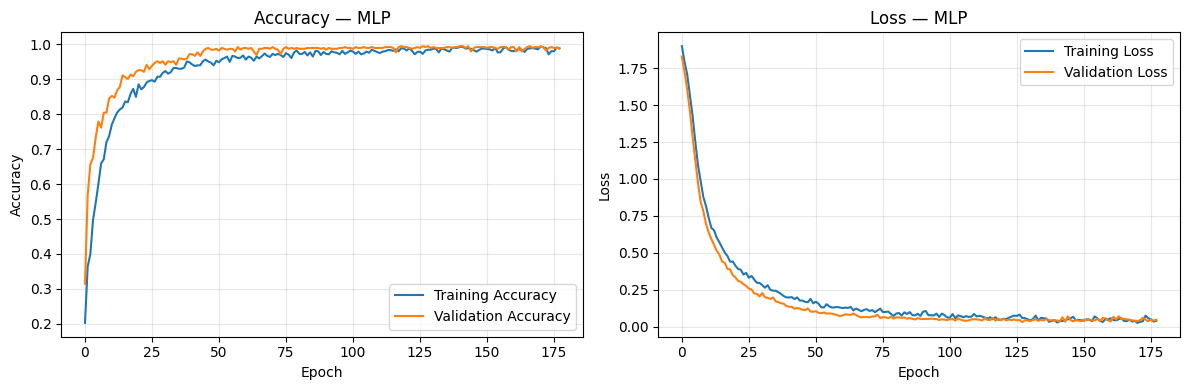

In [27]:
# =============================================================================
# MLP · 2b — Curvas de aprendizaje
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy — %s' % network_type)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss — %s' % network_type)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig('curvas_aprendizaje_MLP.png', dpi=150, bbox_inches='tight')
print('[Figura guardada: curvas_aprendizaje_MLP.png — úsala en la memoria]')
plt.show()


[PERFORMANCE ANALYSIS]
[SETUP]
	[Type of model: MLP]
	[Normalization: LO]
	[Num classes: 6 (+ NO_GESTURE)]

[Train accuracy           = 0.9989]
[Train unweighted f-measure = 0.9989]

[Number of test examples = 394]

[Confusion matrix for test data]
[[57  0  0  0  0  0  0]
 [ 0 54  0  0  1  0  0]
 [ 0  0 56  0  0  0  0]
 [ 0  0  0 57  0  0  0]
 [ 0  0  0  0 56  1  0]
 [ 0  0  0  0  1 55  0]
 [ 0  0  0  0  0  0 56]]

[Test accuracy              = 0.9924]
[Test unweighted f-measure  = 0.9924]
[Test weighted f-measure    = 0.9924]
[Execution time             = 56.55 s]

[Classification report]
                precision    recall  f1-score   support

         No_Ok     1.0000    1.0000    1.0000        57
            OK     1.0000    0.9818    0.9908        55
      Perfecto     1.0000    1.0000    1.0000        56
Puno_de_frente     1.0000    1.0000    1.0000        57
     Spiderman     0.9655    0.9825    0.9739        57
           Uno     0.9821    0.9821    0.9821        56
    NO_GE

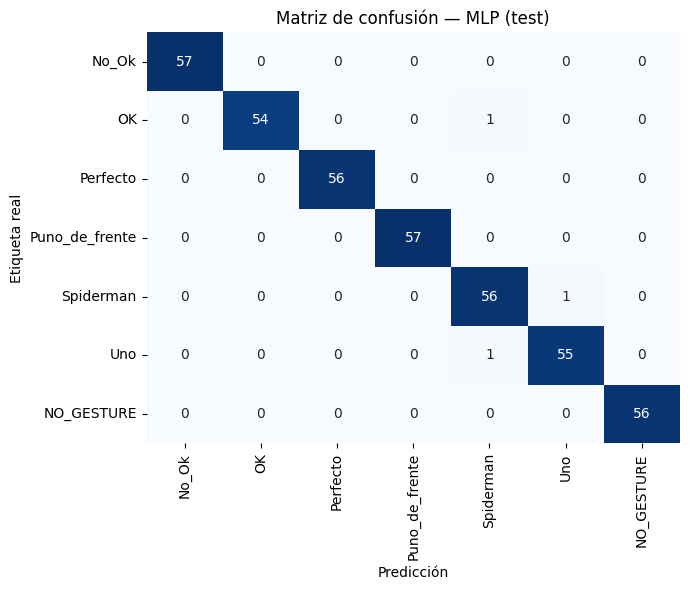


[Confusiones más frecuentes]
	OK               -> Spiderman        : 1
	Spiderman        -> Uno              : 1
	Uno              -> Spiderman        : 1

[model_results] CNN1, CNN2, FINE-TUNING1, FINE-TUNING2, MLP


In [28]:
# =============================================================================
# MLP · 3 — Análisis de rendimiento y registro en model_results
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('\n[PERFORMANCE ANALYSIS]')
print('[SETUP]')
print('\t[Type of model: %s]' % network_type)
print('\t[Normalization: %s]' % norm_type_mlp)
print('\t[Num classes: %d (+ NO_GESTURE)]' % num_classes)

# --- Train ------------------------------------------------------------------
y_pred_train = np.argmax(model.predict(X_train, batch_size=batch_size_mlp, verbose=0), axis=1) + 1
print('\n[Train accuracy           = %0.4f]' % accuracy_score(y_train, y_pred_train))
print('[Train unweighted f-measure = %0.4f]' % f1_score(y_train, y_pred_train, average='macro'))

# --- Test -------------------------------------------------------------------
y_pred = np.argmax(model.predict(X_test, batch_size=batch_size_mlp, verbose=0), axis=1) + 1

acc    = accuracy_score(y_test, y_pred)
f1_unw = f1_score(y_test, y_pred, average='macro')
f1_w   = f1_score(y_test, y_pred, average='weighted')
matrix = confusion_matrix(y_test, y_pred, labels=np.arange(1, len(class_names) + 1))

print('\n[Number of test examples = %d]' % matrix.sum())
print('\n[Confusion matrix for test data]')
print(matrix)
print('\n[Test accuracy              = %0.4f]' % acc)
print('[Test unweighted f-measure  = %0.4f]' % f1_unw)
print('[Test weighted f-measure    = %0.4f]' % f1_w)
print('[Execution time             = %.2f s]' % execution_time)

print('\n[Classification report]')
print(classification_report(y_test, y_pred, labels=np.arange(1, len(class_names) + 1),
                            target_names=class_names, digits=4, zero_division=0))

# --- Matriz de confusión con nombres de clase (figura para la memoria) ------
plt.figure(figsize=(7, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión — %s (test)' % network_type)
plt.xlabel('Predicción'); plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.savefig('matriz_confusion_MLP.png', dpi=150, bbox_inches='tight')
print('[Figura guardada: matriz_confusion_MLP.png — úsala en la memoria]')
plt.show()

# --- Errores por pares de clases (para el análisis de la memoria) -----------
print('\n[Confusiones más frecuentes]')
_errores = [(class_names[i], class_names[j], int(matrix[i, j]))
            for i in range(len(class_names)) for j in range(len(class_names))
            if i != j and matrix[i, j] > 0]
if _errores:
    for _real, _pred, _n in sorted(_errores, key=lambda t: -t[2]):
        print('\t%-16s -> %-16s : %d' % (_real, _pred, _n))
else:
    print('\tNinguna: clasificación perfecta en test.')

# --- Registro en la lista común (sin duplicar si repites la celda) ----------
if 'model_results' not in globals():
    model_results = []

etiqueta_modelo = 'MLP' if norm_type_mlp != 'L0' else 'MLP-L0'
model_results = [r for r in model_results if r['model_type'] != etiqueta_modelo]
model_results.append({
    "model_type": etiqueta_modelo,
    "norm_type": norm_type_mlp,
    "accuracy": acc,
    "f-measure_unweighted": f1_unw,
    "f-measure_weighted": f1_w,
    "execution_time": execution_time
})

print('\n[model_results] %s' % ', '.join(r['model_type'] for r in model_results))

In [29]:
# =============================================================================
# MLP · 4 — Guardado del modelo (.json + .keras)
# =============================================================================
import os

root_filename = 'PIDS_6gestos_v1'
aux = '_L0' if norm_type_mlp == 'L0' else ''

if not os.path.exists(models_path):
    os.makedirs(models_path)

# Descripción de la arquitectura
json_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.json")
print(f'[SAVING MODEL DESCRIPTION][{json_filename}]')
with open(json_filename, 'w') as json_file:
    json_file.write(model.to_json())

# Modelo completo en el formato recomendado de Keras
keras_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.keras")
print(f'[SAVING MODEL][{keras_filename}]')
model.save(keras_filename)

print('[MODEL SAVED!!!]')
print('\t[.keras: %.1f KB]' % (os.path.getsize(keras_filename) / 1024))
print('\t[.json : %.1f KB]' % (os.path.getsize(json_filename) / 1024))

# --- Descarga a tu ordenador (Colab borra /content/ al desconectarse) -------
# Descomenta para bajártelos y poder subirlos al repo en el Pull Request:
# from google.colab import files
# files.download(keras_filename)
# files.download(json_filename)

[SAVING MODEL DESCRIPTION][HAR_mediapipe/models/PIDS_6gestos_v1_MLP.json]
[SAVING MODEL][HAR_mediapipe/models/PIDS_6gestos_v1_MLP.keras]
[MODEL SAVED!!!]
	[.keras: 195.8 KB]
	[.json : 3.9 KB]


In [30]:
# =============================================================================
# MLP · 5 — Coste computacional y viabilidad Edge AI
# =============================================================================
# La memoria pide valorar si el modelo podría ejecutarse en una Raspberry Pi o
# un móvil: tamaño del modelo y tiempo de inferencia.
import time
import numpy as np

num_params = model.count_params()
size_kb = os.path.getsize(keras_filename) / 1024

# Inferencia muestra a muestra (el caso real de la demo con webcam)
_x1 = X_test[:1]
for _ in range(10):                      # warm-up
    _ = model(_x1, training=False)

_n = 200
_t0 = time.perf_counter()
for _ in range(_n):
    _ = model(_x1, training=False)
ms_muestra = (time.perf_counter() - _t0) / _n * 1000

# Inferencia por lotes (todo el test de golpe)
_t0 = time.perf_counter()
_ = model.predict(X_test, batch_size=batch_size_mlp, verbose=0)
ms_lote = (time.perf_counter() - _t0) / len(X_test) * 1000

print('[COSTE COMPUTACIONAL — %s]' % network_type)
print('\t[Parámetros entrenables : %d]' % num_params)
print('\t[Tamaño del fichero     : %.1f KB]' % size_kb)
print('\t[Tiempo de entrenamiento: %.2f s (%d épocas)]' % (execution_time, epochs_ejecutadas))
print('\t[Inferencia 1 muestra   : %.3f ms  -> %.0f fps teóricos]'
      % (ms_muestra, 1000 / ms_muestra))
print('\t[Inferencia por lotes   : %.4f ms/muestra]' % ms_lote)
print('\n[Para la memoria] El cuello de botella de la demo en tiempo real no es el'
      '\nclasificador sino la extracción de landmarks con MediaPipe; conviene medir'
      '\nambos por separado antes de concluir sobre viabilidad en Raspberry Pi.')

[COSTE COMPUTACIONAL — MLP]
	[Parámetros entrenables : 14215]
	[Tamaño del fichero     : 195.8 KB]
	[Tiempo de entrenamiento: 56.55 s (178 épocas)]
	[Inferencia 1 muestra   : 6.405 ms  -> 156 fps teóricos]
	[Inferencia por lotes   : 0.4423 ms/muestra]

[Para la memoria] El cuello de botella de la demo en tiempo real no es el
clasificador sino la extracción de landmarks con MediaPipe; conviene medir
ambos por separado antes de concluir sobre viabilidad en Raspberry Pi.


## Extras — recomendados para la memoria

Las dos celdas siguientes son opcionales pero cubren dos puntos que la guía pide explícitamente en §8:

- `MLP · 6` — **hiperparámetros probados y cuál funcionó mejor**. El MLP entrena en segundos, así que se puede permitir una exploración pequeña. No registra nada en `model_results`: sólo imprime la tabla comparativa.
- `MLP · 7` — **tabla final comparativa** en formato Markdown, lista para pegar en la descripción del Pull Request y en la memoria.

In [31]:
# =============================================================================
# MLP · 6 — Exploración de hiperparámetros (opcional, ~2-5 min)
# =============================================================================
# No toca 'model' ni 'model_results': entrena copias aparte y compara.
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score

# Búsqueda más corta que el entrenamiento final, para que no se eternice
EPOCHS_BUSQUEDA   = 200
PATIENCE_BUSQUEDA = 25

configuraciones = [
    {"capas": (128, 64), "dropout": 0.3, "lr": 1e-3},   # configuración base
    {"capas": (64, 32),  "dropout": 0.3, "lr": 1e-3},   # más pequeña
    {"capas": (256, 128), "dropout": 0.3, "lr": 1e-3},  # más grande
    {"capas": (128, 64), "dropout": 0.1, "lr": 1e-3},   # menos regularización
    {"capas": (128, 64), "dropout": 0.5, "lr": 1e-3},   # más regularización
    {"capas": (128, 64), "dropout": 0.3, "lr": 5e-4},   # lr más bajo
    {"capas": (128, 64, 32), "dropout": 0.3, "lr": 1e-3},  # tres capas ocultas
]

resultados_busqueda = []
for _i, _cfg in enumerate(configuraciones, 1):
    print('\n[%d/%d] capas=%s dropout=%.2f lr=%.0e'
          % (_i, len(configuraciones), _cfg['capas'], _cfg['dropout'], _cfg['lr']))

    np.random.seed(2022)
    tf.random.set_seed(2022)

    _m = Sequential()
    _m.add(Input(shape=(42,)))
    for _u in _cfg['capas']:
        _m.add(Dense(_u, activation='relu'))
        _m.add(Dropout(_cfg['dropout']))
    _m.add(Dense(num_outputs, activation='softmax'))
    _m.compile(loss='categorical_crossentropy',
               optimizer=AdamW(learning_rate=_cfg['lr'], weight_decay=1e-4),
               metrics=['accuracy'])

    _t0 = time.time()
    _h = _m.fit(X_train, y_train_oh, batch_size=batch_size_mlp,
                epochs=EPOCHS_BUSQUEDA, verbose=0, shuffle=True,
                validation_data=(X_test, y_test_oh),
                callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE_BUSQUEDA,
                                         restore_best_weights=True, verbose=0)])
    _t = time.time() - _t0

    _pred = np.argmax(_m.predict(X_test, verbose=0), axis=1) + 1
    resultados_busqueda.append({
        "capas": str(_cfg['capas']),
        "dropout": _cfg['dropout'],
        "lr": _cfg['lr'],
        "params": _m.count_params(),
        "epocas": len(_h.history['loss']),
        "accuracy": accuracy_score(y_test, _pred),
        "f1_macro": f1_score(y_test, _pred, average='macro'),
        "tiempo_s": _t,
    })
    print('\taccuracy=%.4f  f1=%.4f  (%d épocas, %.1f s)'
          % (resultados_busqueda[-1]['accuracy'], resultados_busqueda[-1]['f1_macro'],
             resultados_busqueda[-1]['epocas'], _t))

df_busqueda = pd.DataFrame(resultados_busqueda).sort_values('accuracy', ascending=False)
print('\n[HIPERPARÁMETROS PROBADOS — ordenados por accuracy]')
print(df_busqueda.to_string(index=False))
print('\n[NOTA] Con un test de ~394 muestras, diferencias de 2-3 aciertos (≈0,7 %) están'
      '\ndentro del ruido: no presentes como "mejor" una configuración que sólo gana por eso.'
      '\nUsa los intervalos de confianza de la sección de comparación para justificarlo.')


[1/7] capas=(128, 64) dropout=0.30 lr=1e-03
	accuracy=0.9924  f1=0.9924  (141 épocas, 41.6 s)

[2/7] capas=(64, 32) dropout=0.30 lr=1e-03
	accuracy=0.9924  f1=0.9924  (200 épocas, 55.6 s)

[3/7] capas=(256, 128) dropout=0.30 lr=1e-03
	accuracy=0.9924  f1=0.9924  (141 épocas, 41.5 s)

[4/7] capas=(128, 64) dropout=0.10 lr=1e-03
	accuracy=0.9898  f1=0.9898  (178 épocas, 49.4 s)

[5/7] capas=(128, 64) dropout=0.50 lr=1e-03
	accuracy=0.9924  f1=0.9924  (176 épocas, 50.4 s)

[6/7] capas=(128, 64) dropout=0.30 lr=5e-04
	accuracy=0.9873  f1=0.9873  (200 épocas, 55.5 s)

[7/7] capas=(128, 64, 32) dropout=0.30 lr=1e-03
	accuracy=0.9949  f1=0.9949  (200 épocas, 58.4 s)

[HIPERPARÁMETROS PROBADOS — ordenados por accuracy]
        capas  dropout     lr  params  epocas  accuracy  f1_macro  tiempo_s
(128, 64, 32)      0.3 0.0010   16071     200  0.994924  0.994939 58.441118
     (64, 32)      0.3 0.0010    5063     200  0.992386  0.992389 55.630565
    (128, 64)      0.3 0.0010   14215     141  0.9

In [32]:
# =============================================================================
# MLP · 7 — Tabla comparativa final (para el PR y la memoria)
# =============================================================================
import pandas as pd

df_resultados = pd.DataFrame(model_results)
df_resultados = df_resultados.rename(columns={
    "model_type": "Modelo", "norm_type": "Normalización", "accuracy": "Test accuracy",
    "f-measure_unweighted": "F-measure (macro)", "f-measure_weighted": "F-measure (pond.)",
    "execution_time": "Tiempo (s)"})

df_fmt = df_resultados.copy()
for _c in ["Test accuracy", "F-measure (macro)", "F-measure (pond.)"]:
    df_fmt[_c] = (df_fmt[_c] * 100).map('{:.2f} %'.format)
df_fmt["Tiempo (s)"] = df_fmt["Tiempo (s)"].map('{:.1f}'.format)

print('[COMPARATIVA DE MODELOS]')
print(df_fmt.to_string(index=False))

print('\n[Markdown — pégalo en la descripción del Pull Request]\n')
try:
    print(df_fmt.to_markdown(index=False))
except Exception:
    _cols = list(df_fmt.columns)
    print('| ' + ' | '.join(_cols) + ' |')
    print('|' + '|'.join(['---'] * len(_cols)) + '|')
    for _, _row in df_fmt.iterrows():
        print('| ' + ' | '.join(str(_row[c]) for c in _cols) + ' |')

print('\n[RECORDATORIO] El tiempo de los 4 modelos de referencia se midió de forma'
      '\ndistinta (incluye predicción y tiempo muerto entre celdas). Indícalo en la'
      '\nmemoria antes de afirmar que el MLP es "N veces más rápido".')

[COMPARATIVA DE MODELOS]
      Modelo Normalización Test accuracy F-measure (macro) F-measure (pond.) Tiempo (s)
        CNN1            LO       99.24 %           99.24 %           99.24 %      229.3
        CNN2            LO       91.37 %           91.48 %           91.44 %      394.5
FINE-TUNING1            LO       99.49 %           99.49 %           99.49 %      106.8
FINE-TUNING2            LO       99.24 %           99.24 %           99.24 %       87.1
         MLP            LO       99.24 %           99.24 %           99.24 %       56.5

[Markdown — pégalo en la descripción del Pull Request]

| Modelo       | Normalización   | Test accuracy   | F-measure (macro)   | F-measure (pond.)   |   Tiempo (s) |
|:-------------|:----------------|:----------------|:--------------------|:--------------------|-------------:|
| CNN1         | LO              | 99.24 %         | 99.24 %             | 99.24 %             |        229.3 |
| CNN2         | LO              | 91.37 %         | 9

## Qué entregar cuando termines

Según §7 de la guía, el Pull Request lleva tres cosas:

1. **Este notebook**, en `parte1_reconocimiento_gestos/HAR_mediapipe/notebooks/HAR_mediapipe_MLP.ipynb`
2. **El modelo entrenado** (`PIDS_6gestos_v1_MLP.keras` y su `.json`), en `parte1_reconocimiento_gestos/HAR_mediapipe/modelos/`
3. **Las métricas** (accuracy, f-measure ponderada y sin ponderar, tiempo de entrenamiento y matriz de confusión) en la descripción del PR — la celda `MLP · 7` las imprime ya en Markdown.

```bash
git checkout main
git pull
git checkout -b feat/modelo-mlp

# ... copias el notebook y el modelo a sus carpetas ...

git add parte1_reconocimiento_gestos/HAR_mediapipe/notebooks/HAR_mediapipe_MLP.ipynb
git add parte1_reconocimiento_gestos/HAR_mediapipe/modelos/PIDS_6gestos_v1_MLP.*
git commit -m "feat(gestos): Evaluar modelo MLP sobre el dataset del equipo"
git push -u origin feat/modelo-mlp
```

⚠️ Antes del commit, `git status`: no subas imágenes ni el dataset.

**Además, plantea al equipo** el tema de `norm_type` (`"LO"` vs `"L0"`) descrito al principio de esta sección: afecta a cómo se interpretan los resultados de los cinco modelos, no sólo al tuyo.

# Systems Comparison


In this last section, we will compare results obtained from our trained models.


Comparing models is a common practice in the field of machine learning and data science to determine which model provides the best performance for a particular problem. When comparing models, the goal is to identify which one is capable of making more accurate and generalizable predictions.

When comparing models, it is important to consider the number of samples you are working with. The sample size can have a significant impact on the performance of the models and the reliability of the evaluation metrics. Depending on whether you have used cross-validation or split the data into train and test sets.

**TO DO:**
Modify the accuracy values in the cell below with the accuracy reached by your models and comment the results.
You will use either the total number of data or the number of test data when indicating the variable "num_sample_test".

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  # Seaborn way of setting style

# Compare accuracy and f-score
model_types = [result['model_type'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
fmeasure_unweighted = [result['f-measure_unweighted'] for result in model_results]
fmeasure_weighted = [result['f-measure_weighted'] for result in model_results]

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(model_types))

# Accuracy (accuracy)
ax.plot(x, accuracies, marker='o', label='Accuracy')

# F-score  (unweighted fmeasure)
ax.plot(x, fmeasure_unweighted, marker='o', label='F-measure (Unweighted)')

# F-score  (weighted fmeasure)
ax.plot(x, fmeasure_weighted, marker='o', label='F-measure (Weighted)')

ax.set_xticks(x)
ax.set_xticklabels(model_types, rotation=45)

ax.set_title('comparison of models')
ax.set_xlabel('Models')
ax.set_ylabel('Value')

ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

execution_times = [result['execution_time'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
model_types = [result['model_type'] for result in model_results]

# Create scatter plot
plt.scatter(execution_times, accuracies)

# Label each point with the model type
for i, model_type in enumerate(model_types):
    plt.annotate(model_type, (execution_times[i], accuracies[i]))

# Axis labels
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Accuracy')

# Plot title
plt.title('Comparison of Execution Time and Accuracy for Models')

# Show the plot
plt.show()

In [ ]:
model_results

In [ ]:
# USING CONFIDENCE INTERVALS
from evaluation import CalculateCI, find_best_result

num_samples = test_data.shape[0]

"""
num_samples is the amount of test data if we use split into  train - test and
we use the total amount of data if we use cross validation
"""

model_type_to_search = 'CNN1'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_cnn1 = 100*model_results[best_index]['accuracy']
CI_cnn1 = CalculateCI(num_samples, acc_cnn1)
print('[CNN1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn1, acc_cnn1-CI_cnn1, acc_cnn1+CI_cnn1))

### Run only when evaluating with the CNN2 option

In [ ]:
model_type_to_search = 'CNN2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_cnn2 = 100*model_results[best_index]['accuracy']
CI_cnn2 = CalculateCI(num_samples, acc_cnn2)
print('[CNN2][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn2, acc_cnn2-CI_cnn2, acc_cnn2+CI_cnn2))

### Run only when evaluating with the FINE-TUNNING1 option

In [ ]:
model_type_to_search = 'FINE-TUNING1'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_fine_tunning1 = 100*model_results[best_index]['accuracy']
CI_fine_tunning1 = CalculateCI(num_samples, acc_fine_tunning1)
print('[FINE-TUNING1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning1, acc_fine_tunning1-CI_fine_tunning1, acc_fine_tunning1+CI_fine_tunning1))

### Run only when evaluating with the FINE-TUNNING2 option

In [ ]:
model_type_to_search = 'FINE-TUNING2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_fine_tunning2 = 100*model_results[best_index]['accuracy']
CI_fine_tunning2 = CalculateCI(num_samples, acc_fine_tunning2)
print('[FINE-TUNING1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning2, acc_fine_tunning2-CI_fine_tunning2, acc_fine_tunning2+CI_fine_tunning2))

The best result for model type 'FINE-TUNING2' is at index 3.
{'model_type': 'FINE-TUNING2', 'norm_type': 'LO', 'accuracy': 0.9923857868020305, 'f-measure_unweighted': 0.9924110869119689, 'f-measure_weighted': 0.9924066737172234, 'execution_time': 87.08207774162292}
[FINE-TUNING1][accuracy = 99.24 (98.38, 100.10)]


## Final plot

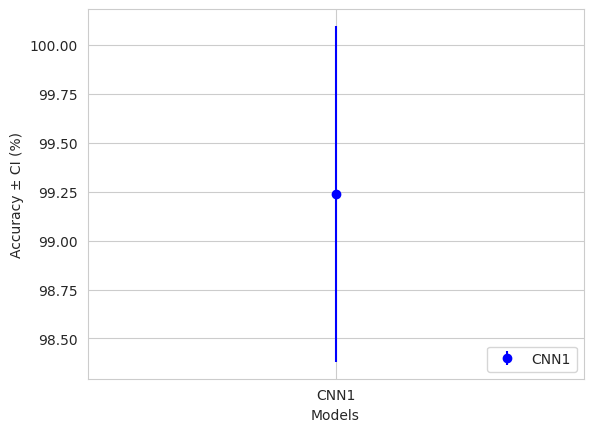

In [ ]:
# PLOT RESULTS
import matplotlib.pyplot as plt
import numpy as np

# ARRAYS/INFO TO PLOT
means = [acc_cnn1]
CI = [CI_cnn1]
model_labels = ['CNN1']

# WITH FINETUNED MODELS
#means = [acc_cnn1, acc_cnn2, acc_fine_tunning1, acc_fine_tunning2]
#CI = [CI_cnn1, CI_cnn2, CI_fine_tunning1, CI_fine_tunning2]
#model_labels = ['CNN1', 'CNN2', 'FINE-TUNING1', 'FINE-TUNING2']


# PLOT DATA
fig, ax = plt.subplots(1)
plt.errorbar([0], [acc_cnn1], yerr=[CI_cnn1], fmt='o', label='CNN1', color="blue")
#plt.errorbar([1], [acc_cnn2], yerr=[CI_cnn2], fmt='o', label='CNN2', color="red")
#plt.errorbar([2], [acc_fine_tunning1], yerr=[CI_fine_tunning1], fmt='o', label='FINE-TUNNING1', color="green")
#plt.errorbar([3], [acc_fine_tunning2], yerr=[CI_fine_tunning2], fmt='o', label='FINE-TUNNING2', color="yellow")

#PLOT FORMAT
#plt.xlim(-0.5, 3.5)
plt.legend(loc='lower right')
plt.ylabel('Accuracy ± CI (%)')
plt.xlabel('Models')
plt.xticks(range(len(model_labels)), model_labels)

plt.show()